Sinh viên thực hiện : Phạm Ngọc Thịnh 

1. IMPORT CÁC THƯ VIỆN 

In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

print("Đã import thành công các thư viện!")

Đã import thành công các thư viện!


2.TẢI DATA (Kaggle)VÀ XỬ LÝ DỮ LIỆU 

In [5]:
path_train = r"../../../data/spaceship/train.csv"
path_test = r"../../../data/spaceship/test.csv"
train_df = pd.read_csv(path_train)
test_df = pd.read_csv(path_test)
print(f"Kích thước tập Train: {train_df.shape}")
print(f"Kích thước tập Test: {test_df.shape}")

# Hiển thị 5 dòng đầu tiên của tập train
train_df.head()

Kích thước tập Train: (8693, 14)
Kích thước tập Test: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [18]:
# Kiểm tra tỷ lệ missing values và kiểu dữ liệu
print("MISSING VALUES TẬP TRAIN ")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

print("\nBIẾN MỤC TIÊU (Transported) ")
print(train_df['Transported'].value_counts(normalize=True))

MISSING VALUES TẬP TRAIN 
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
dtype: int64

BIẾN MỤC TIÊU (Transported) 
Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


EDA dataset

C:\Users\DELL\AppData\Local\Temp\ipykernel_3612\888954589.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values, y=missing.index, palette="viridis")


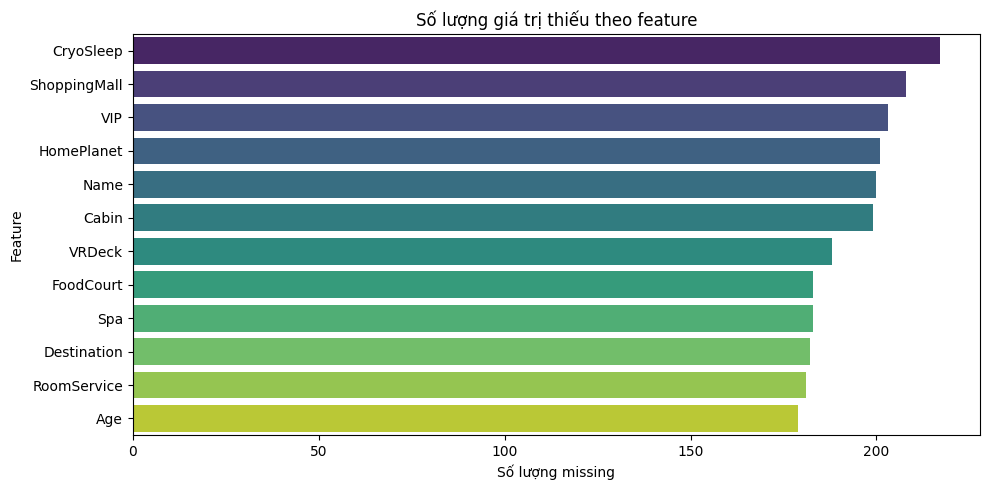

In [20]:
#Tỷ lệ missing values
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing.values, y=missing.index, palette="viridis")
plt.title("Số lượng giá trị thiếu theo feature")
plt.xlabel("Số lượng missing")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Nhận xét:** Các feature có missing values tập trung chủ yếu ở một số cột như Cabin, Age và các biến chi tiêu. Điều này cho thấy dữ liệu cần tiền xử lý kỹ trước khi huấn luyện mô hình.

C:\Users\DELL\AppData\Local\Temp\ipykernel_3612\919412622.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x="Transported", ax=ax[0], palette="Set2")
C:\Users\DELL\AppData\Local\Temp\ipykernel_3612\919412622.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x="HomePlanet", ax=ax[1], palette="Set3")
C:\Users\DELL\AppData\Local\Temp\ipykernel_3612\919412622.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x="Destination", ax=ax[2], palette="Set1")


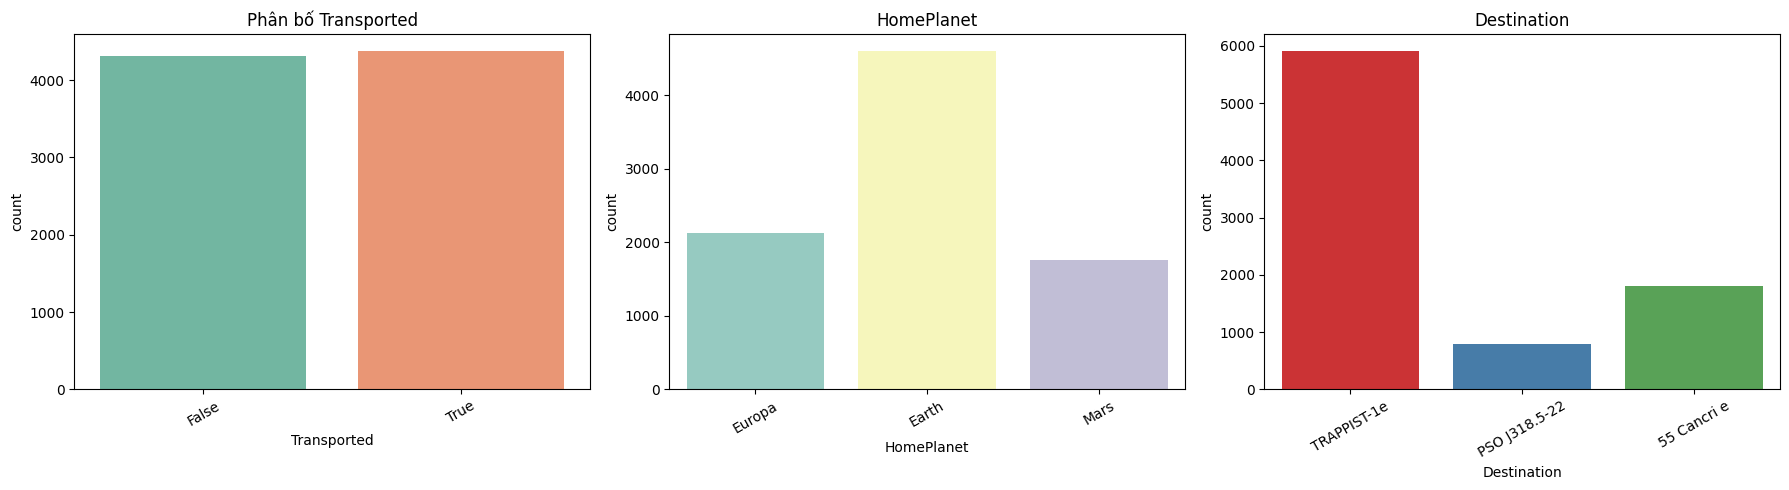

In [21]:
#Phân bố biến mục tiêu và một vài feature phân loại
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=train_df, x="Transported", ax=ax[0], palette="Set2")
ax[0].set_title("Phân bố Transported")
sns.countplot(data=train_df, x="HomePlanet", ax=ax[1], palette="Set3")
ax[1].set_title("HomePlanet")
sns.countplot(data=train_df, x="Destination", ax=ax[2], palette="Set1")
ax[2].set_title("Destination")
for a in ax:
    a.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Nhận xét:** Biến mục tiêu `Transported` khá cân bằng nên không bị lệch lớp nghiêm trọng. Các feature phân loại như `HomePlanet` và `Destination` có phân bố không đồng đều, có thể ảnh hưởng đến khả năng dự đoán.

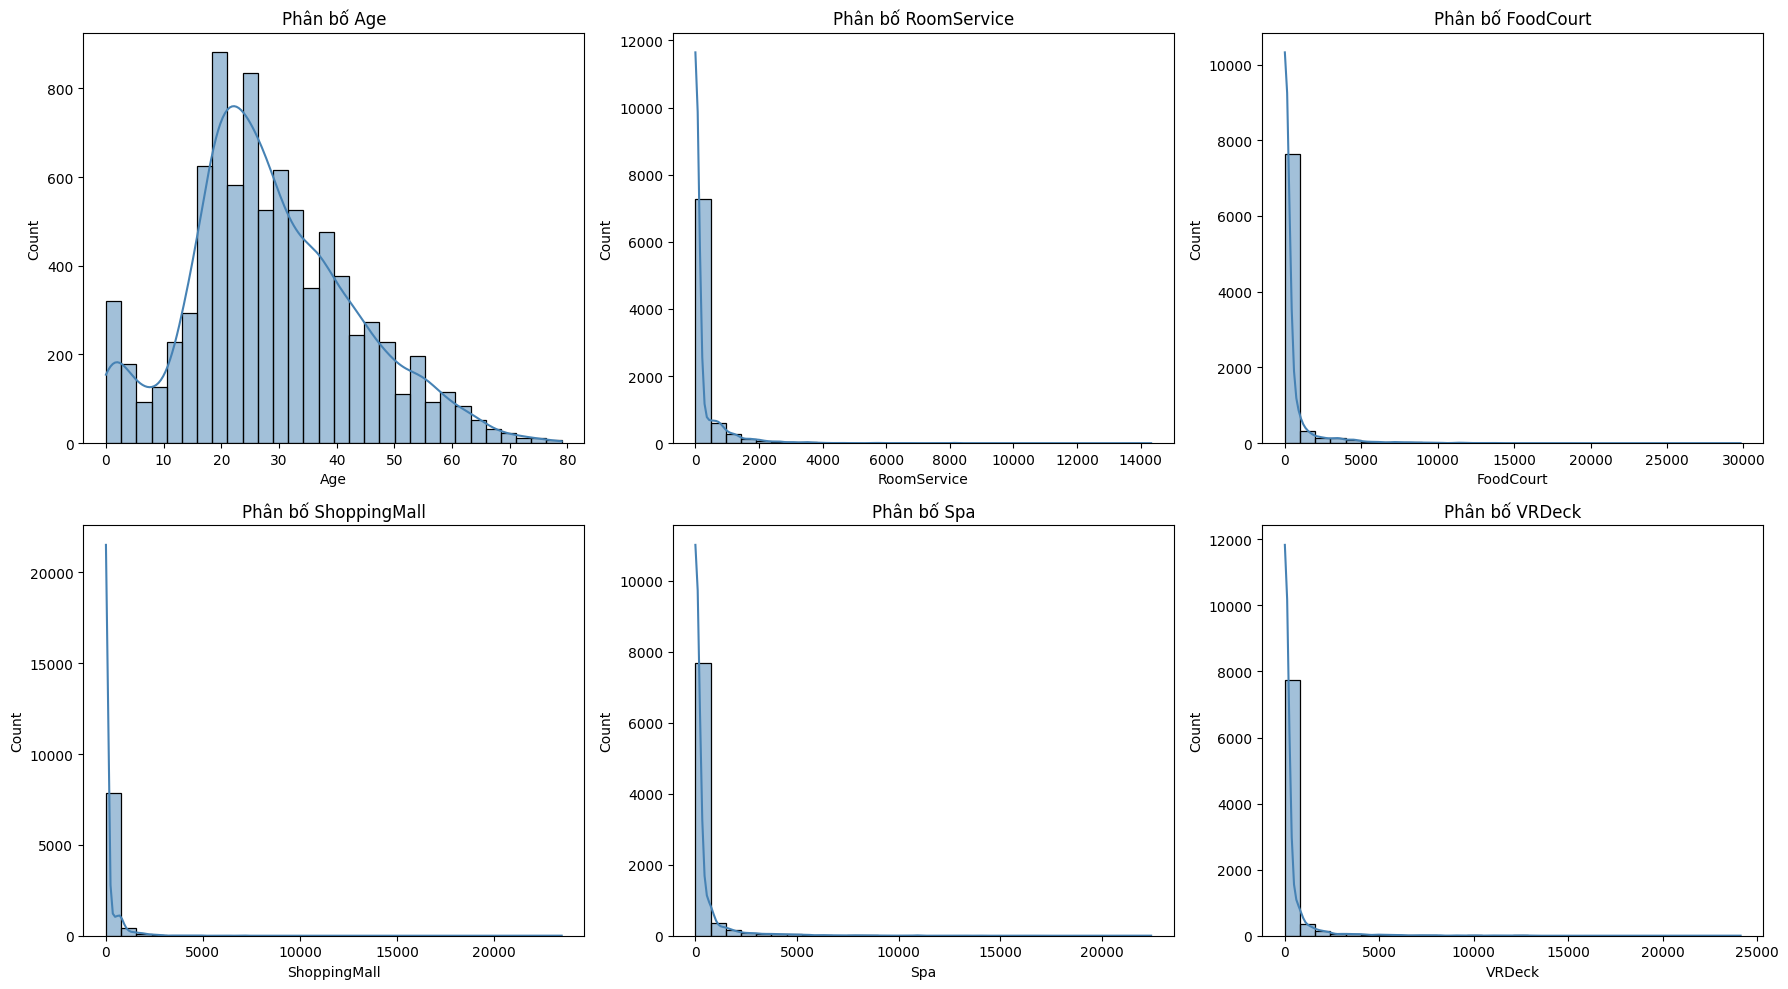

In [22]:
#Phân bố các feature số
num_cols = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.histplot(data=train_df, x=col, kde=True, bins=30, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Phân bố {col}")
plt.tight_layout()
plt.show()

**Nhận xét:** Một số biến số như `RoomService`, `FoodCourt`, `Spa`, `VRDeck` bị lệch phải mạnh, phần lớn giá trị tập trung gần 0. Điều này cho thấy nhiều hành khách gần như không sử dụng dịch vụ trên tàu.

C:\Users\DELL\AppData\Local\Temp\ipykernel_3612\4056918424.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x="Transported", y=col, ax=axes[i], palette="Set2")
C:\Users\DELL\AppData\Local\Temp\ipykernel_3612\4056918424.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x="Transported", y=col, ax=axes[i], palette="Set2")
C:\Users\DELL\AppData\Local\Temp\ipykernel_3612\4056918424.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x="Transported", y=col, ax=axes[i], palette="Set2")
C:\Users\DELL

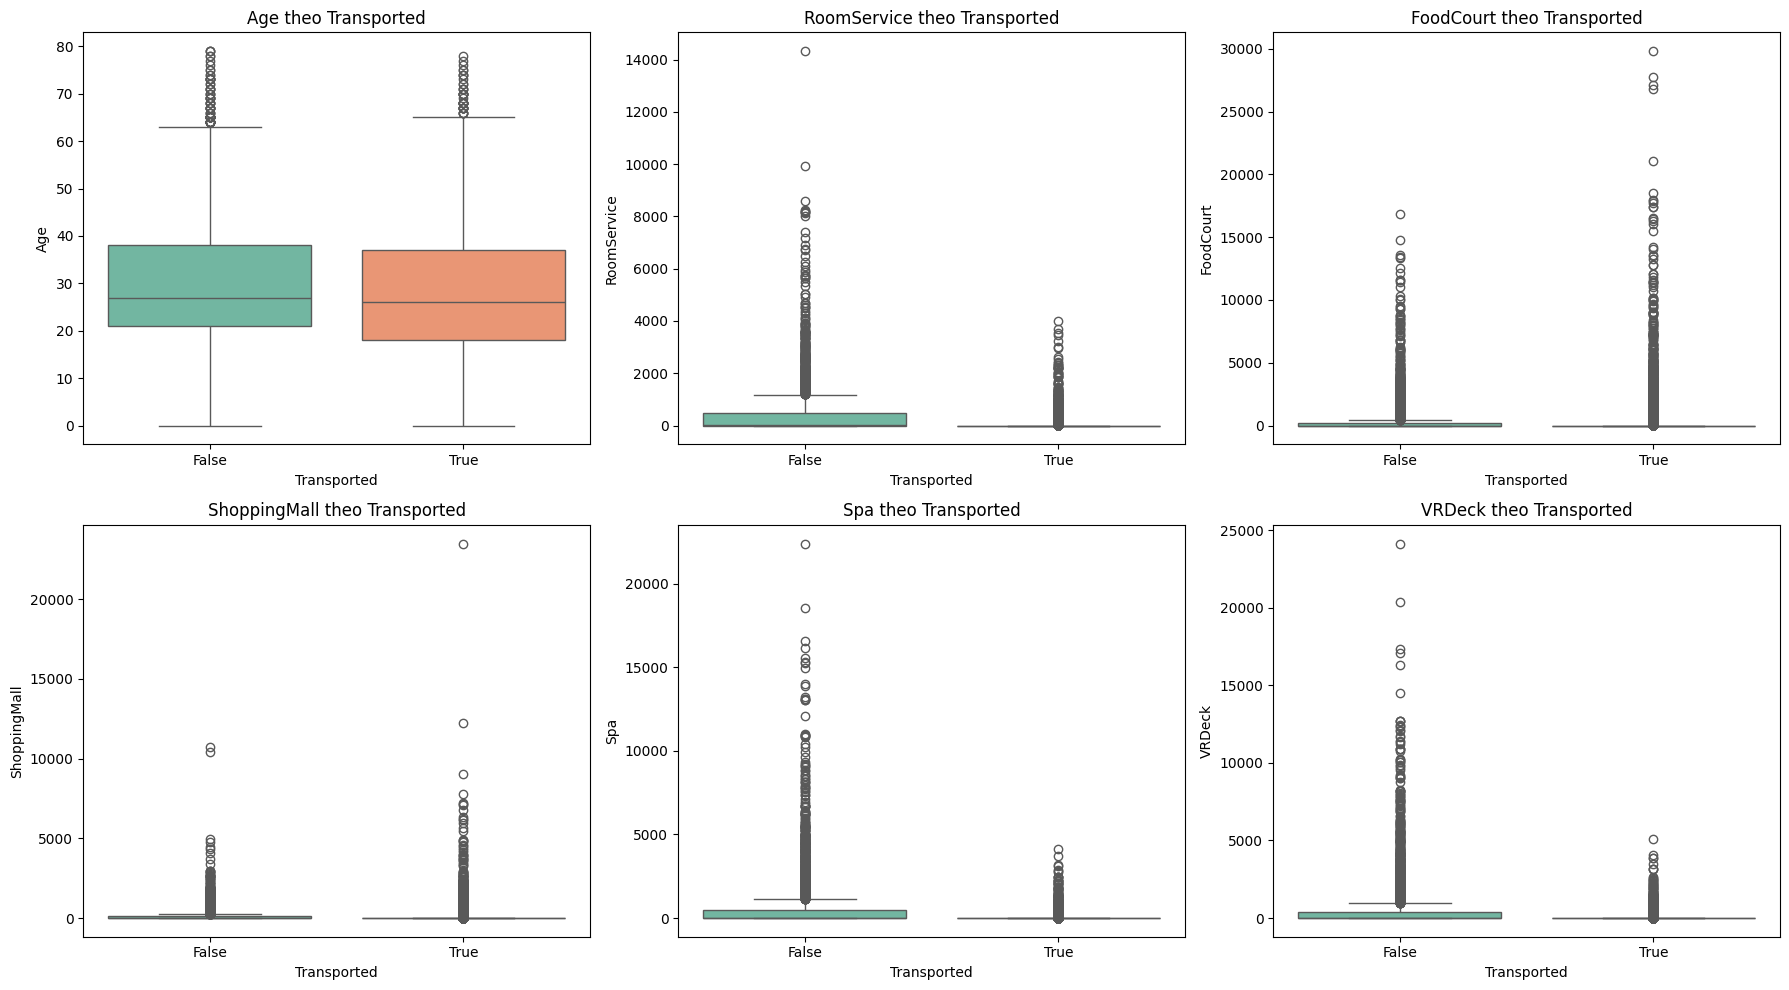

In [23]:
#Boxplot feature số theo Transported
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    sns.boxplot(data=train_df, x="Transported", y=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} theo Transported")

plt.tight_layout()
plt.show()

**Nhận xét:** Các nhóm `Transported` và `Not Transported` có khác biệt ở một số biến chi tiêu. Đặc biệt, hành khách chi tiêu thấp hoặc bằng 0 có xu hướng được vận chuyển nhiều hơn.

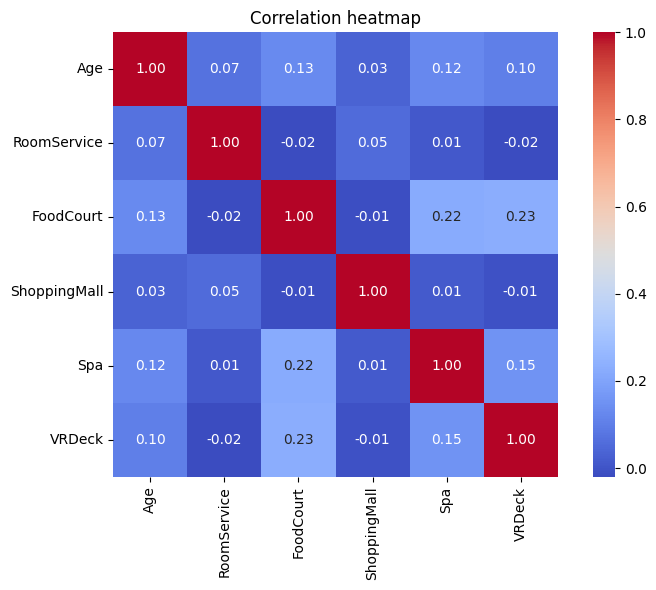

In [24]:
#ma trận tương quan các biến số
corr_cols = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
corr = train_df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

**Nhận xét:** Các biến chi tiêu có tương quan với nhau ở mức vừa phải, cho thấy chúng phản ánh cùng một hành vi sử dụng dịch vụ. Tuy nhiên, mức tương quan không quá cao nên vẫn có giá trị khi giữ lại trong mô hình.

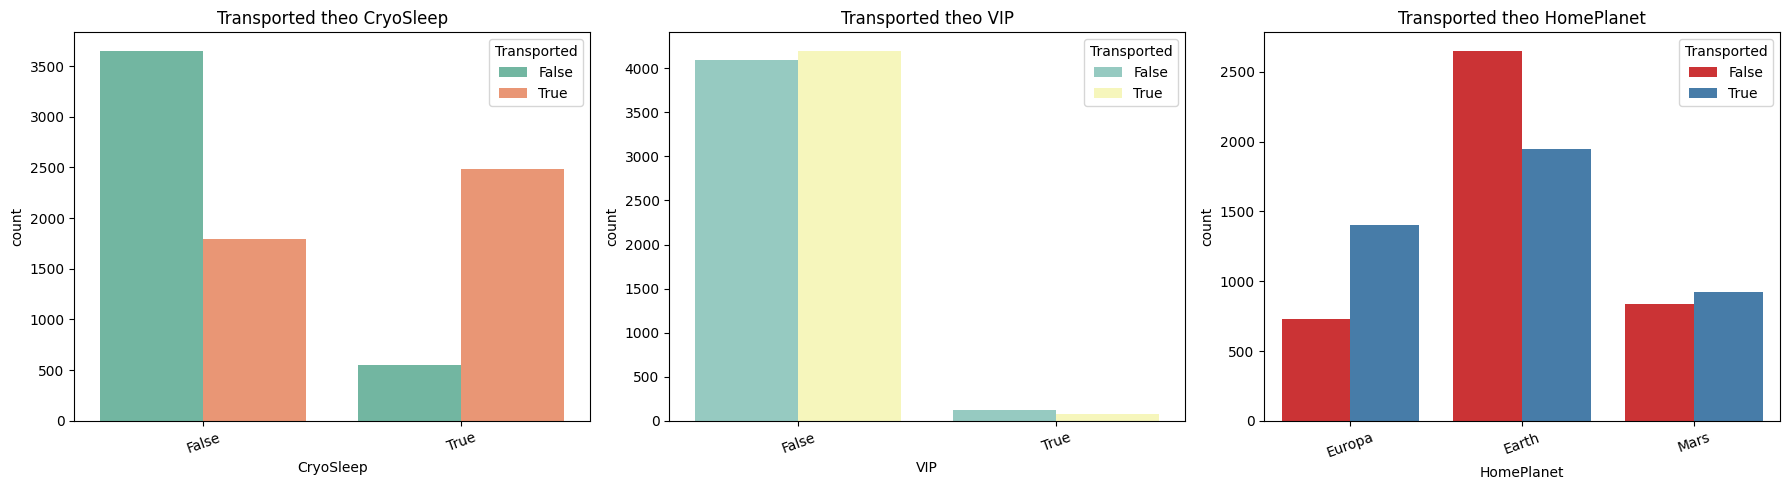

In [ ]:
#Transported theo CryoSleep, VIP và HomePlanet
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=train_df, x='CryoSleep', hue='Transported', ax=ax[0], palette='Set2')
ax[0].set_title('Transported theo CryoSleep')
sns.countplot(data=train_df, x='VIP', hue='Transported', ax=ax[1], palette='Set3')
ax[1].set_title('Transported theo VIP')
sns.countplot(data=train_df, x='HomePlanet', hue='Transported', ax=ax[2], palette='Set1')
ax[2].set_title('Transported theo HomePlanet')

for a in ax:
    a.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

**Nhận xét:** `CryoSleep` có vẻ là một feature quan trọng vì tỷ lệ Transported giữa các nhóm khác nhau khá rõ. Ngược lại, `VIP` thường có số lượng ít hơn nên tín hiệu từ biến này có thể không mạnh bằng.

3. TIỀN XỬ LÝ DỮ LIỆU & FEATURE ENGINEERING

In [7]:
def preprocess_data(df):
    df = df.copy()
    
    #Tách cột Cabin thành: Deck, Num, Side
    if 'Cabin' in df.columns:
        df[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = df['Cabin'].str.split('/', expand=True)
        df['Cabin_Num'] = pd.to_numeric(df['Cabin_Num'], errors='coerce')
        df.drop(columns=['Cabin'], inplace=True)
        
    #Trích xuất họ (Surname) từ PassengerId hoặc Name 
    if 'Name' in df.columns:
        df['Surname'] = df['Name'].str.split(' ').str[-1]
        df.drop(columns=['Name'], inplace=True)
    else:
        df['Surname'] = 'Unknown'
        
    #Tạo tính năng tổng chi phí dịch vụ (Total Spending)
    spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    for col in spending_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    df['Total_Spending'] = df[spending_cols].sum(axis=1)
    df['No_Spending'] = (df['Total_Spending'] == 0).astype(int)
    
    #Xử lý cột tuổi (Age) và gán nhóm tuổi
    if 'Age' in df.columns:
        df['Age'] = df['Age'].fillna(df['Age'].median())
        df['AgeGroup'] = pd.cut(df['Age'], bins=[-1, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])
        df['AgeGroup'] = df['AgeGroup'].astype(str)

    #điền data missing
    bool_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_Deck', 'Cabin_Side']
    for col in bool_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Missing')
            
    
    if 'PassengerId' in df.columns:#loại PassengerId vì không dùng cho dự báo hành vi
        df.drop(columns=['PassengerId'], inplace=True)
        
    return df

# Áp dụng hàm tiền xử lý
train_processed = preprocess_data(train_df)
test_processed = preprocess_data(test_df)

# Tách biến mục tiêu ra khỏi tập train
X = train_processed.drop(columns=['Transported'])
y = train_processed['Transported'].astype(int)
X_test = test_processed.copy()

print("Kích thước X sau feature engineering:", X.shape)

Kích thước X sau feature engineering: (8693, 17)


C:\Users\DELL\AppData\Local\Temp\ipykernel_3612\2127796554.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Missing')
C:\Users\DELL\AppData\Local\Temp\ipykernel_3612\2127796554.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Missing')


4. XÂY DỰNG PIPELINE TIỀN XỬ LÝ SỐ HỌC VÀ CATEGORICAL

In [8]:
numerical_cols = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("Đã hoàn tất processing data và pipeline")

Đã hoàn tất processing data và pipeline


5. XÂY DỰNG VÀ HUẤN LUYỆN CÁC MÔ HÌNH CƠ SỞ (BASE MODELS)

In [ ]:
rf_model = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))])
xgb_model = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', XGBClassifier(n_estimators=200, learning_rate=0.05, random_state=42, eval_metric='logloss'))])
lgbm_model = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1))])
cat_model = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', CatBoostClassifier(iterations=300, learning_rate=0.05, random_state=42, verbose=0))])

base_models = {
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgbm_model,
    'CatBoost': cat_model
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
for name, model in base_models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results[name] = scores.mean()
    print(f"{name} CV Accuracy: {scores.mean():.4f} và std value: {scores.std():.4f}")

Random Forest CV Accuracy: 0.8014 và std value: 0.0082
XGBoost CV Accuracy: 0.8098 và std value: 0.0066
LightGBM CV Accuracy: 0.8111 và std value: 0.0052
CatBoost CV Accuracy: 0.8067 và std value: 0.0085


6. KỸ THUẬT ENSEMBLE LEARNING (VOTING & STACKING)

In [11]:
#Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('cat', cat_model)
    ],
    voting='soft'
)
voting_scores = cross_val_score(voting_clf, X, y, cv=cv, scoring='accuracy')
print(f"Voting Classifier CV Accuracy: {voting_scores.mean():.4f}")

#Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('cat', cat_model)
    ],
    final_estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    cv=5
)
stacking_scores = cross_val_score(stacking_clf, X, y, cv=cv, scoring='accuracy')
print(f"Stacking Classifier CV Accuracy: {stacking_scores.mean():.4f}")

Voting Classifier CV Accuracy: 0.8117
Stacking Classifier CV Accuracy: 0.7873


7. ĐÁNH GIÁ VÀ SO SÁNH BENCHMARK

In [ ]:
all_results = results.copy()
all_results['Voting Ensemble'] = voting_scores.mean()
all_results['Stacking Ensemble'] = stacking_scores.mean()
benchmark_df = pd.DataFrame(list(all_results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)
print("\nBẢNG SO SÁNH BENCHMARK CÁC MÔ HÌNH ")
display(benchmark_df)


BẢNG SO SÁNH BENCHMARK CÁC MÔ HÌNH 


,Model,Accuracy
4,Voting Ensemble,0.811688
2,LightGBM,0.811112
1,XGBoost,0.809847
3,CatBoost,0.806741
0,Random Forest,0.801449
5,Stacking Ensemble,0.787302


8. DỰ ĐOÁN TRÊN TẬP TEST VÀ XUẤT KẾT QUẢ

In [13]:
#Huấn luyện mô hình 
best_model = stacking_clf 
best_model.fit(X, y)
#Dự đoán trên tập test
test_predictions = best_model.predict(X_test)
test_predictions_bool = test_predictions.astype(bool)

#Lấy PassengerId từ file test
original_test_df = pd.read_csv(path_test)
submission = pd.DataFrame({
    'PassengerId': original_test_df['PassengerId'],
    'Transported': test_predictions_bool
})

# Lưu file submission
submission.to_csv('submission.csv', index=False)
print("Đã xuất file submission.csv thành công!")

Đã xuất file submission.csv thành công!


In [15]:
# In ra vài dòng đầu của file submission
ket_qua= pd.read_csv('submission.csv')
display(ket_qua.head())

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False
